1

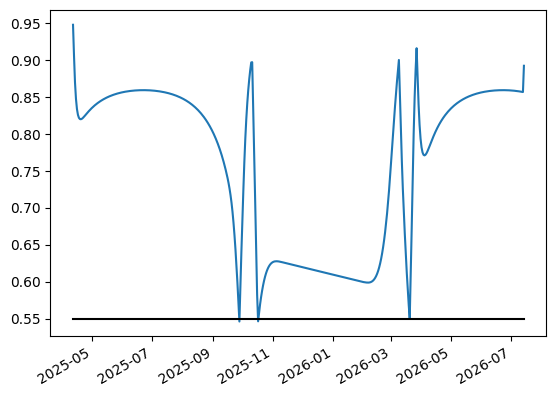

In [160]:
import importlib
import numpy as np
import pandas as pd
import SolarCalc as SC
import matplotlib.pyplot as plt
importlib.reload(SC)

sa=SC.System(
    Timestamp=['2025-04-12 01:00','2026-07-14 00:00','60min'],
    Latitude=69,
    Longitude=-135,
    transmissivity=0.6,
    UTC=False,
    Slope=62.5,
    Full_Load_Watts=24,
    Discharge_Limit=0.55,
    Batt_Sequences_in_Parallel=12
    )

sa.TrackState()

df = pd.DataFrame(index=sa.Timestamp,data={'Supply_Amp_Hours':sa.Supply_Amp_Hours,
                                           'Supply_pct_Available':sa.Supply_pct_Available})

df = df.resample('D').min()

fig = plt.figure()
plt.plot(df.index,df.Supply_pct_Available)
plt.plot(df.index,df.Supply_pct_Available*0+sa.Discharge_Limit,color='k')
fig.autofmt_xdate()
sa.System_On